แทนค่า missng

In [35]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [64]:
# โหลดไฟล์ Excel (sheet2)
df = pd.read_excel("/content/new data.xlsx", sheet_name="Sheet2")

In [65]:
df

,Date,Showalter,Lifted,SWEAT,K,Cross,Vertical,TT Totals,CAPE,CIN,BRN,LCL Temp,LCL P,LCL P.1,MML θ,MML q,Thickness,PWAT,dBZ
0,2018-02-01,13.29,16.28,244.92,-27.1,5.7,19.7,25.4,0,0,0,276.14,783.2,314.16,296.13,6.16,5749,12.64,0.0
1,2018-02-02,10.78,11.77,127.18,-22.1,10.3,19.3,29.6,0,0,0,281.45,839.9,319.96,295.87,8.3,5746,16.33,0.0
2,2018-02-03,3.53,4.54,362.3,-14.3,19.3,19.7,39,15.68,-46.73,0.86,288.03,903.9,331.01,296.49,11.91,5729,25.68,0.0
3,2018-02-04,4.66,5.24,200.4,-18,18.8,19.3,38.1,0,-50.25,0,285.99,879.04,327.88,296.74,10.71,5734,22.45,0.0
4,2018-02-05,7.09,8.06,170.99,-0.7,15.3,18.3,33.6,0,0,0,285.51,868.8,327.84,297.24,10.51,5733,22.85,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,2021-02-08,-4.55,-5.04,352.01,40,25.5,30.3,55.8,318.19,-95.93,3.38,289.19,896,336.27,298.43,13,5695,38.11,36.5
368,2021-02-09,0.55,2.57,162.58,2,23,23.7,46.7,6.52,-108.75,0.17,284.68,877.22,324.07,295.55,9.87,5636,22.42,31.5
369,2021-02-10,8.44,9.02,142.21,-4.7,13.7,19.7,33.4,0,0,0,284.29,880.49,322.46,294.84,9.55,5677,19.51,44.0
370,2021-02-11,10.57,10.84,103.01,-18.9,10.1,20.1,30.2,0,0,0,283.37,871.98,320.92,294.7,9.08,5721,18.15,39.0


In [39]:
df.isna().sum()

,0
Date,0
Showalter,0
Lifted,0
SWEAT,0
K,0
Cross,0
Vertical,0
TT Totals,0
CAPE,0
CIN,0


In [66]:
# แทนค่า '-' ด้วย NaN
df = df.replace("-", np.nan)

/tmp/ipython-input-4259720604.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


In [67]:
X = df.drop('Date', axis=1, errors='ignore')
y = df['dBZ']

In [68]:
X

,Showalter,Lifted,SWEAT,K,Cross,Vertical,TT Totals,CAPE,CIN,BRN,LCL Temp,LCL P,LCL P.1,MML θ,MML q,Thickness,PWAT,dBZ
0,13.29,16.28,244.92,-27.1,5.7,19.7,25.4,0.00,0.00,0.00,276.14,783.20,314.16,296.13,6.16,5749.0,12.64,0.0
1,10.78,11.77,127.18,-22.1,10.3,19.3,29.6,0.00,0.00,0.00,281.45,839.90,319.96,295.87,8.30,5746.0,16.33,0.0
2,3.53,4.54,362.30,-14.3,19.3,19.7,39.0,15.68,-46.73,0.86,288.03,903.90,331.01,296.49,11.91,5729.0,25.68,0.0
3,4.66,5.24,200.40,-18.0,18.8,19.3,38.1,0.00,-50.25,0.00,285.99,879.04,327.88,296.74,10.71,5734.0,22.45,0.0
4,7.09,8.06,170.99,-0.7,15.3,18.3,33.6,0.00,0.00,0.00,285.51,868.80,327.84,297.24,10.51,5733.0,22.85,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,-4.55,-5.04,352.01,40.0,25.5,30.3,55.8,318.19,-95.93,3.38,289.19,896.00,336.27,298.43,13.00,5695.0,38.11,36.5
368,0.55,2.57,162.58,2.0,23.0,23.7,46.7,6.52,-108.75,0.17,284.68,877.22,324.07,295.55,9.87,5636.0,22.42,31.5
369,8.44,9.02,142.21,-4.7,13.7,19.7,33.4,0.00,0.00,0.00,284.29,880.49,322.46,294.84,9.55,5677.0,19.51,44.0
370,10.57,10.84,103.01,-18.9,10.1,20.1,30.2,0.00,0.00,0.00,283.37,871.98,320.92,294.70,9.08,5721.0,18.15,39.0


In [18]:
# แยกเฉพาะตัวเลข
#X = X.apply(pd.to_numeric, errors='coerce')
#y = pd.to_numeric(y, errors='coerce')

In [69]:
# ===== 2. สร้าง DataFrame สำหรับเติมค่า =====
df_full = pd.concat([X, y], axis=1)
df_full

,Showalter,Lifted,SWEAT,K,Cross,Vertical,TT Totals,CAPE,CIN,BRN,LCL Temp,LCL P,LCL P.1,MML θ,MML q,Thickness,PWAT,dBZ,dBZ
0,13.29,16.28,244.92,-27.1,5.7,19.7,25.4,0.00,0.00,0.00,276.14,783.20,314.16,296.13,6.16,5749.0,12.64,0.0,0.0
1,10.78,11.77,127.18,-22.1,10.3,19.3,29.6,0.00,0.00,0.00,281.45,839.90,319.96,295.87,8.30,5746.0,16.33,0.0,0.0
2,3.53,4.54,362.30,-14.3,19.3,19.7,39.0,15.68,-46.73,0.86,288.03,903.90,331.01,296.49,11.91,5729.0,25.68,0.0,0.0
3,4.66,5.24,200.40,-18.0,18.8,19.3,38.1,0.00,-50.25,0.00,285.99,879.04,327.88,296.74,10.71,5734.0,22.45,0.0,0.0
4,7.09,8.06,170.99,-0.7,15.3,18.3,33.6,0.00,0.00,0.00,285.51,868.80,327.84,297.24,10.51,5733.0,22.85,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,-4.55,-5.04,352.01,40.0,25.5,30.3,55.8,318.19,-95.93,3.38,289.19,896.00,336.27,298.43,13.00,5695.0,38.11,36.5,36.5
368,0.55,2.57,162.58,2.0,23.0,23.7,46.7,6.52,-108.75,0.17,284.68,877.22,324.07,295.55,9.87,5636.0,22.42,31.5,31.5
369,8.44,9.02,142.21,-4.7,13.7,19.7,33.4,0.00,0.00,0.00,284.29,880.49,322.46,294.84,9.55,5677.0,19.51,44.0,44.0
370,10.57,10.84,103.01,-18.9,10.1,20.1,30.2,0.00,0.00,0.00,283.37,871.98,320.92,294.70,9.08,5721.0,18.15,39.0,39.0


In [70]:
import numpy as np

df_full = df_full.replace("-", np.nan)
df_full

,Showalter,Lifted,SWEAT,K,Cross,Vertical,TT Totals,CAPE,CIN,BRN,LCL Temp,LCL P,LCL P.1,MML θ,MML q,Thickness,PWAT,dBZ,dBZ
0,13.29,16.28,244.92,-27.1,5.7,19.7,25.4,0.00,0.00,0.00,276.14,783.20,314.16,296.13,6.16,5749.0,12.64,0.0,0.0
1,10.78,11.77,127.18,-22.1,10.3,19.3,29.6,0.00,0.00,0.00,281.45,839.90,319.96,295.87,8.30,5746.0,16.33,0.0,0.0
2,3.53,4.54,362.30,-14.3,19.3,19.7,39.0,15.68,-46.73,0.86,288.03,903.90,331.01,296.49,11.91,5729.0,25.68,0.0,0.0
3,4.66,5.24,200.40,-18.0,18.8,19.3,38.1,0.00,-50.25,0.00,285.99,879.04,327.88,296.74,10.71,5734.0,22.45,0.0,0.0
4,7.09,8.06,170.99,-0.7,15.3,18.3,33.6,0.00,0.00,0.00,285.51,868.80,327.84,297.24,10.51,5733.0,22.85,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,-4.55,-5.04,352.01,40.0,25.5,30.3,55.8,318.19,-95.93,3.38,289.19,896.00,336.27,298.43,13.00,5695.0,38.11,36.5,36.5
368,0.55,2.57,162.58,2.0,23.0,23.7,46.7,6.52,-108.75,0.17,284.68,877.22,324.07,295.55,9.87,5636.0,22.42,31.5,31.5
369,8.44,9.02,142.21,-4.7,13.7,19.7,33.4,0.00,0.00,0.00,284.29,880.49,322.46,294.84,9.55,5677.0,19.51,44.0,44.0
370,10.57,10.84,103.01,-18.9,10.1,20.1,30.2,0.00,0.00,0.00,283.37,871.98,320.92,294.70,9.08,5721.0,18.15,39.0,39.0


In [71]:
df_full.isna().sum()

,0
Showalter,67
Lifted,66
SWEAT,67
K,67
Cross,67
Vertical,67
TT Totals,67
CAPE,66
CIN,66
BRN,68


In [82]:
df = pd.read_csv("/content/Clean_dataset_Date.csv")
df

,Showalter,Lifted,SWEAT,K,Cross,Vertical,TT Totals,CAPE,CIN,BRN,...,MML q,Thickness,PWAT,dBZ,Year,Month,Day,Weekday,DayOfYear,Hour
0,13.29,16.28,244.92,-27.1,5.7,19.7,25.4,0.00,0.00,0.00,...,6.16,5749.0,12.64,0.0,2018,2,1,3,32,0
1,10.78,11.77,127.18,-22.1,10.3,19.3,29.6,0.00,0.00,0.00,...,8.30,5746.0,16.33,0.0,2018,2,2,4,33,0
2,3.53,4.54,362.30,-14.3,19.3,19.7,39.0,15.68,-46.73,0.86,...,11.91,5729.0,25.68,0.0,2018,2,3,5,34,0
3,4.66,5.24,200.40,-18.0,18.8,19.3,38.1,0.00,-50.25,0.00,...,10.71,5734.0,22.45,0.0,2018,2,4,6,35,0
4,7.09,8.06,170.99,-0.7,15.3,18.3,33.6,0.00,0.00,0.00,...,10.51,5733.0,22.85,0.0,2018,2,5,0,36,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-4.55,-5.04,352.01,40.0,25.5,30.3,55.8,318.19,-95.93,3.38,...,13.00,5695.0,38.11,36.5,2021,2,8,0,39,0
299,0.55,2.57,162.58,2.0,23.0,23.7,46.7,6.52,-108.75,0.17,...,9.87,5636.0,22.42,31.5,2021,2,9,1,40,0
300,8.44,9.02,142.21,-4.7,13.7,19.7,33.4,0.00,0.00,0.00,...,9.55,5677.0,19.51,44.0,2021,2,10,2,41,0
301,10.57,10.84,103.01,-18.9,10.1,20.1,30.2,0.00,0.00,0.00,...,9.08,5721.0,18.15,39.0,2021,2,11,3,42,0


In [88]:
df.isna().sum()

,0
Showalter,0
Lifted,0
SWEAT,0
K,0
Cross,0
Vertical,0
TT Totals,0
CAPE,0
CIN,0
BRN,0


In [83]:
# ===== 3. เติมค่า missing =====
# Linear Interpolation
linear_df = df_full.interpolate(method='linear')

# Polynomial Interpolation (order=2)
poly_df = df_full.interpolate(method='polynomial', order=2)

# Spline Interpolation (order=3)
spline_df = df_full.interpolate(method='spline', order=3)

# Moving Average / Rolling Mean (window=3, center=True)
ma_df = df_full.fillna(df_full.rolling(window=3, min_periods=1, center=True).mean())

In [84]:
linear_df.to_excel("data_linear_interpolated_ARM.xlsx", index=False)
poly_df.to_excel("data_polynomial_interpolated_ARM.xlsx", index=False)
spline_df.to_excel("data_spline_interpolated_ARM.xlsx", index=False)
ma_df.to_excel("data_moving_average_ARM.xlsx", index=False)

Model

In [85]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [86]:
# โหลดข้อมูลจาก Excel
df1 = pd.read_excel("/content/data_linear_interpolated_ARM.xlsx")
df2 = pd.read_excel("/content/data_moving_average_ARM.xlsx")
df3 = pd.read_excel("/content/data_polynomial_interpolated_ARM.xlsx")
df4 = pd.read_excel("/content/data_spline_interpolated_ARM.xlsx")

In [21]:
print(df.columns)

Index(['Date', 'Showalter', 'Lifted', 'SWEAT', 'K', 'Cross', 'Vertical',
       'TT Totals', 'CAPE', 'CIN', 'BRN', 'LCL Temp', 'LCL P', 'LCL P.1',
       'MML θ', 'MML q', 'Thickness', 'PWAT', 'dBZ'],
      dtype='object')


In [90]:
# X = df.drop('Date', axis=1)
# y = df['dBZ']

X = df.drop(columns=['dBZ'])
y = df['dBZ']

# แปลง non-numeric ให้เป็น NaN
#X = X.apply(pd.to_numeric, errors='coerce')

# ===== Polynomial Interpolation =====
#X_imputed = X.interpolate(method='polynomial', order=2)

# ===== Linear Interpolation =====
X_linear = X.interpolate(method='linear')

# ===== Polynomial Interpolation (degree=2) =====
X_poly = X.interpolate(method='polynomial', order=2)

# ===== Spline Interpolation (cubic spline = order 3) =====
X_spline = X.interpolate(method='spline', order=3)

# ===== Moving Average / Rolling Mean =====
# ค่าเฉลี่ยรอบๆ ขนาดหน้าต่าง 3 วัน
X_ma = X.fillna(X.rolling(window=3, min_periods=1, center=True).mean())


Missing values ก่อนแทน:
Showalter    0
Lifted       0
SWEAT        0
K            0
Cross        0
Vertical     0
TT Totals    0
CAPE         0
CIN          0
BRN          0
LCL Temp     0
LCL P        0
LCL P.1      0
MML θ        0
MML q        0
Thickness    0
PWAT         0
dBZ          0
Year         0
Month        0
Day          0
Weekday      0
DayOfYear    0
Hour         0
dtype: int64

===== Linear Interpolation =====
           Showalter    Lifted     SWEAT         K     Cross  Vertical  \
Showalter   1.000000  0.914971 -0.677465 -0.714610 -0.955775 -0.437509   
Lifted      0.914971  1.000000 -0.599370 -0.730225 -0.854465 -0.413173   
SWEAT      -0.677465 -0.599370  1.000000  0.501006  0.760828 -0.123700   
K          -0.714610 -0.730225  0.501006  1.000000  0.647350  0.288108   
Cross      -0.955775 -0.854465  0.760828  0.647350  1.000000  0.205177   
Vertical   -0.437509 -0.413173 -0.123700  0.288108  0.205177  1.000000   
TT Totals  -0.964054 -0.872045  0.549446  0.649162 

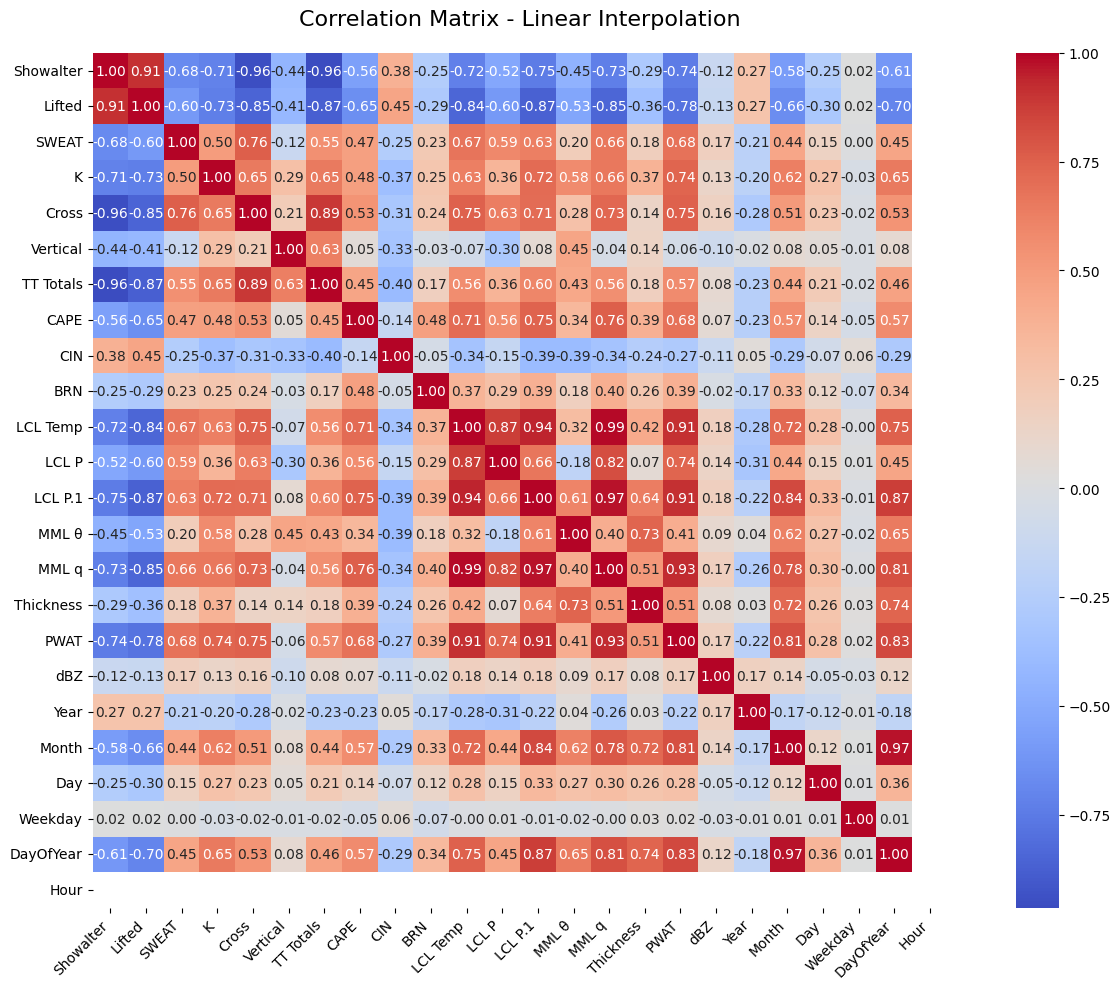


===== Polynomial Interpolation =====
           Showalter    Lifted     SWEAT         K     Cross  Vertical  \
Showalter   1.000000  0.914971 -0.677465 -0.714610 -0.955775 -0.437509   
Lifted      0.914971  1.000000 -0.599370 -0.730225 -0.854465 -0.413173   
SWEAT      -0.677465 -0.599370  1.000000  0.501006  0.760828 -0.123700   
K          -0.714610 -0.730225  0.501006  1.000000  0.647350  0.288108   
Cross      -0.955775 -0.854465  0.760828  0.647350  1.000000  0.205177   
Vertical   -0.437509 -0.413173 -0.123700  0.288108  0.205177  1.000000   
TT Totals  -0.964054 -0.872045  0.549446  0.649162  0.892014  0.625412   
CAPE       -0.561824 -0.654586  0.473165  0.479972  0.533276  0.051588   
CIN         0.378761  0.451023 -0.250875 -0.365858 -0.307275 -0.327847   
BRN        -0.252209 -0.287170  0.230028  0.253101  0.237258 -0.034797   
LCL Temp   -0.724000 -0.842895  0.672252  0.630522  0.749973 -0.072948   
LCL P      -0.519771 -0.601994  0.593069  0.361968  0.632174 -0.303264   


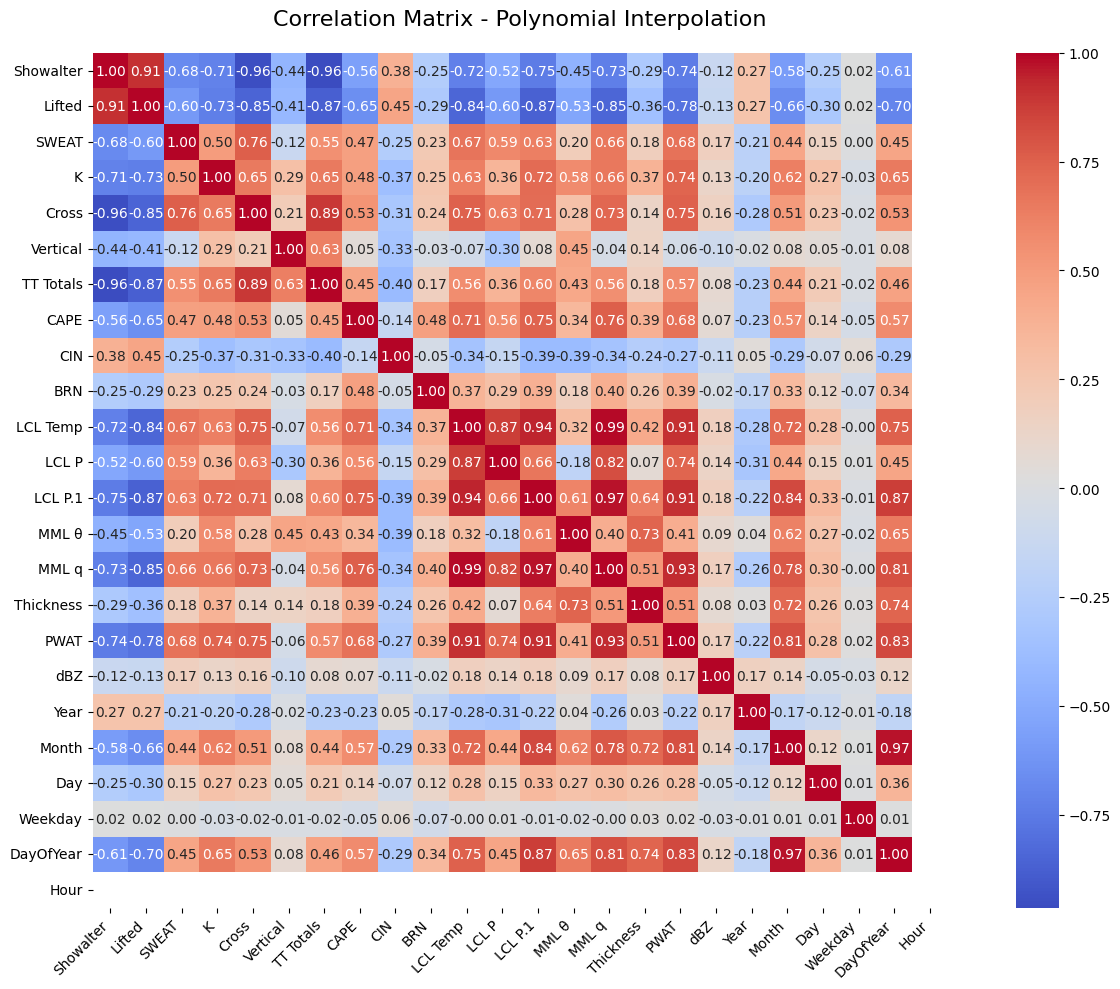


===== Spline Interpolation =====
           Showalter    Lifted     SWEAT         K     Cross  Vertical  \
Showalter   1.000000  0.914971 -0.677465 -0.714610 -0.955775 -0.437509   
Lifted      0.914971  1.000000 -0.599370 -0.730225 -0.854465 -0.413173   
SWEAT      -0.677465 -0.599370  1.000000  0.501006  0.760828 -0.123700   
K          -0.714610 -0.730225  0.501006  1.000000  0.647350  0.288108   
Cross      -0.955775 -0.854465  0.760828  0.647350  1.000000  0.205177   
Vertical   -0.437509 -0.413173 -0.123700  0.288108  0.205177  1.000000   
TT Totals  -0.964054 -0.872045  0.549446  0.649162  0.892014  0.625412   
CAPE       -0.561824 -0.654586  0.473165  0.479972  0.533276  0.051588   
CIN         0.378761  0.451023 -0.250875 -0.365858 -0.307275 -0.327847   
BRN        -0.252209 -0.287170  0.230028  0.253101  0.237258 -0.034797   
LCL Temp   -0.724000 -0.842895  0.672252  0.630522  0.749973 -0.072948   
LCL P      -0.519771 -0.601994  0.593069  0.361968  0.632174 -0.303264   
LCL 

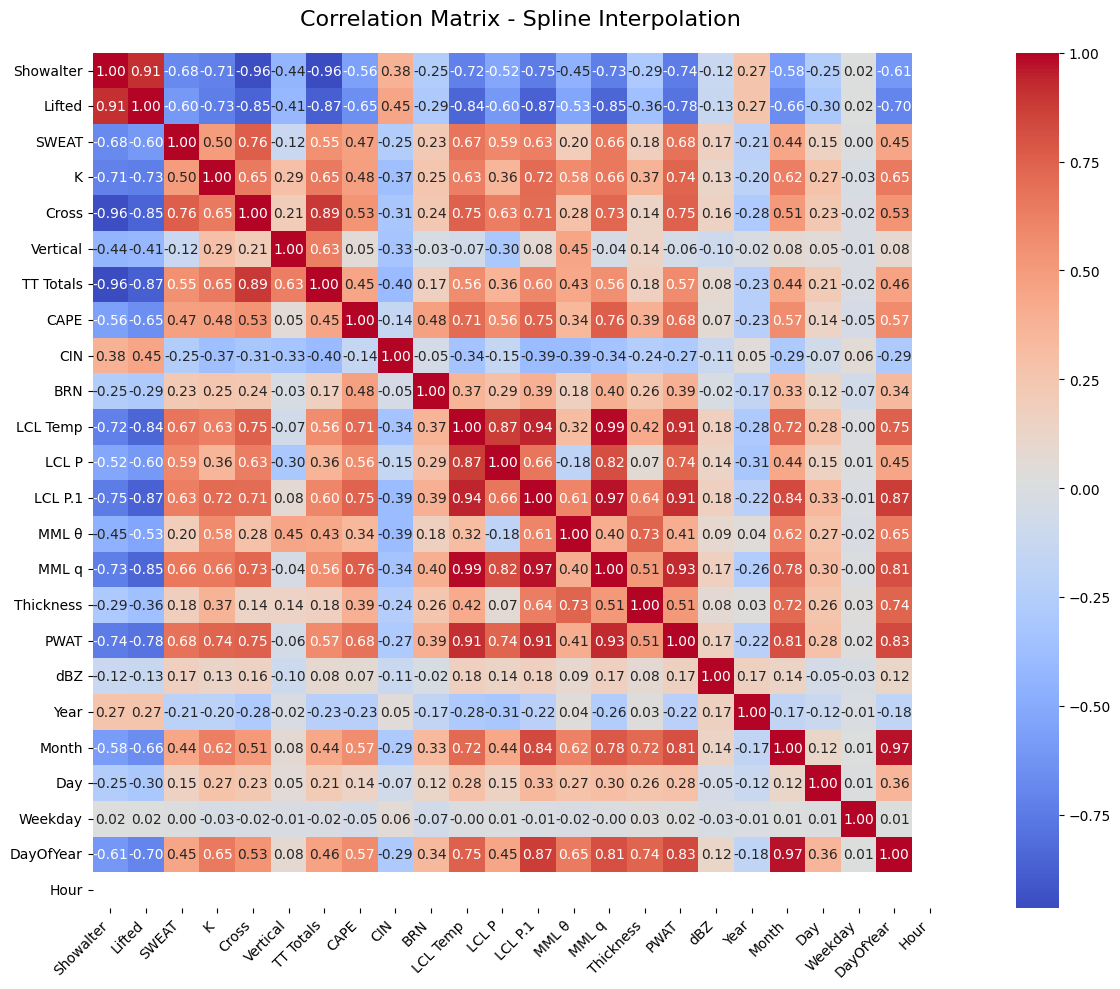


===== Moving Average =====
           Showalter    Lifted     SWEAT         K     Cross  Vertical  \
Showalter   1.000000  0.914971 -0.677465 -0.714610 -0.955775 -0.437509   
Lifted      0.914971  1.000000 -0.599370 -0.730225 -0.854465 -0.413173   
SWEAT      -0.677465 -0.599370  1.000000  0.501006  0.760828 -0.123700   
K          -0.714610 -0.730225  0.501006  1.000000  0.647350  0.288108   
Cross      -0.955775 -0.854465  0.760828  0.647350  1.000000  0.205177   
Vertical   -0.437509 -0.413173 -0.123700  0.288108  0.205177  1.000000   
TT Totals  -0.964054 -0.872045  0.549446  0.649162  0.892014  0.625412   
CAPE       -0.561824 -0.654586  0.473165  0.479972  0.533276  0.051588   
CIN         0.378761  0.451023 -0.250875 -0.365858 -0.307275 -0.327847   
BRN        -0.252209 -0.287170  0.230028  0.253101  0.237258 -0.034797   
LCL Temp   -0.724000 -0.842895  0.672252  0.630522  0.749973 -0.072948   
LCL P      -0.519771 -0.601994  0.593069  0.361968  0.632174 -0.303264   
LCL P.1   

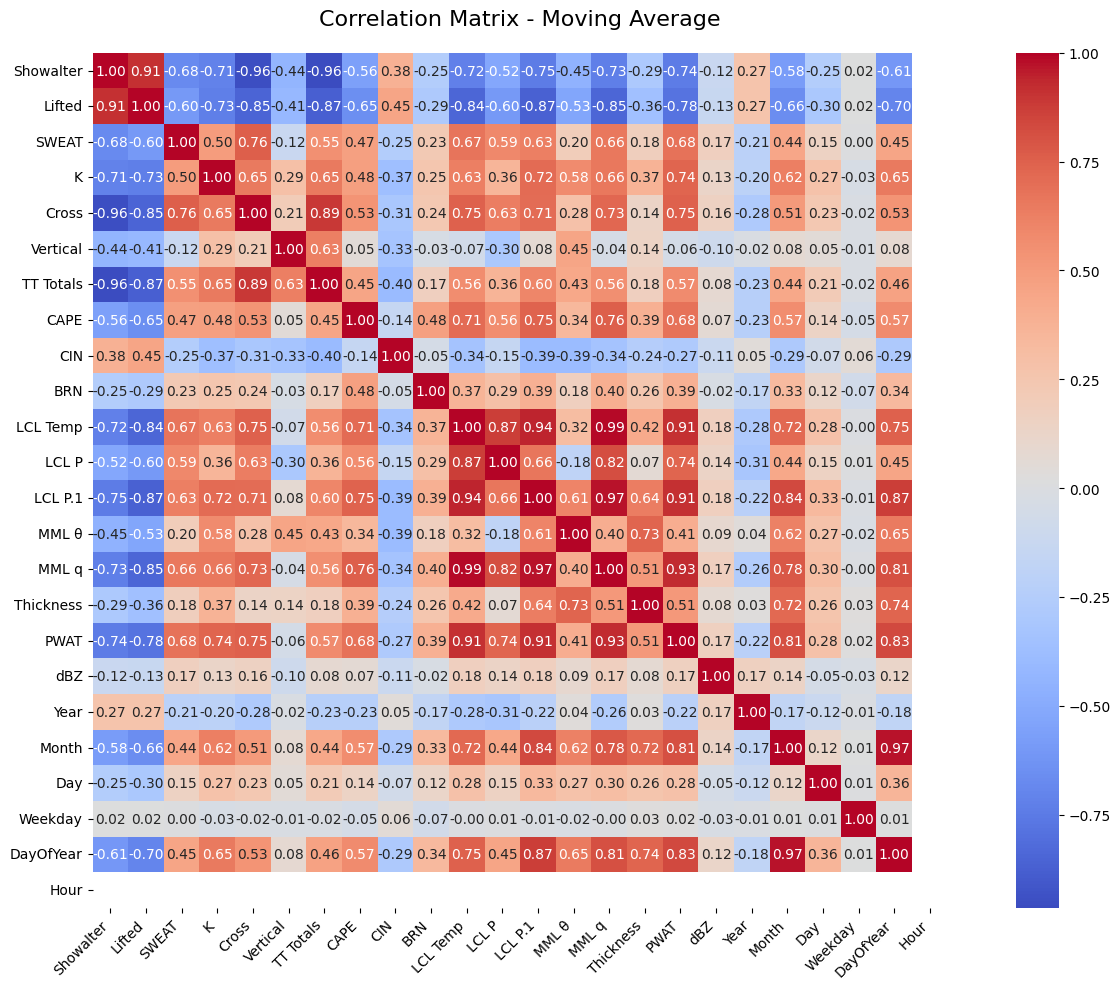

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ====== 1. เตรียมข้อมูล ======
# (สมมติ df คือ DataFrame ที่โหลดมาแล้ว และมี missing values)
# ตรวจสอบ missing
print("Missing values ก่อนแทน:")
print(df.isna().sum())

# ====== 2. Imputation Methods ======
# Linear Interpolation
linear_df = df.interpolate(method='linear')

# Polynomial Interpolation (order=2)
poly_df = df.interpolate(method='polynomial', order=2)

# Spline Interpolation (order=2)
spline_df = df.interpolate(method='spline', order=2)

# Moving Average (Rolling Mean, window=3)
ma_df = df.fillna(df.rolling(window=3, min_periods=1).mean())

# รวมไว้ใน dict
imputed_dfs = {
    "Linear Interpolation": linear_df,
    "Polynomial Interpolation": poly_df,
    "Spline Interpolation": spline_df,
    "Moving Average": ma_df
}

# ====== 3. ดู Correlation ของแต่ละวิธี ======
for name, imputed in imputed_dfs.items():
    print(f"\n===== {name} =====")
    corr = imputed.corr(numeric_only=True)
    print(corr)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="coolwarm", cbar=True, square=True
    )
    plt.title(f"Correlation Matrix - {name}", fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [95]:
# # ------------------- เลือกตัวแปรที่สัมพันธ์กับ y -------------------
# target = 'dBZ'   # กำหนด target ที่สนใจ
# corr_with_y = correlation_matrix[target].sort_values(ascending=False)

# print("Correlation with target (dBZ):")
# print(corr_with_y)

# # ------------------- เลือกตัวแปรที่มีค่า correlation เกิน threshold -------------------
# threshold = 0.9  # กำหนดเกณฑ์ (เช่น |corr| >= 0.9)
# selected_features = corr_with_y[abs(corr_with_y) >= threshold].index.tolist()

# # ลบ target ออกจาก list
# selected_features = [f for f in selected_features if f != target]

# print("\nSelected Features (|corr| >= 0.9):")
# print(selected_features)

Correlation with target (dBZ):
dBZ          1.000000
Date         0.197103
LCL Temp     0.171716
SWEAT        0.170515
LCL P.1      0.169923
MML q        0.167635
Cross        0.161753
K            0.134563
LCL P        0.127117
MML θ        0.093682
TT Totals    0.086117
CAPE         0.068195
Thickness    0.052916
PWAT         0.032085
BRN         -0.023100
Vertical    -0.092954
CIN         -0.120204
Showalter   -0.125767
Lifted      -0.126423
Name: dBZ, dtype: float64

Selected Features (|corr| >= 0.9):
[]


In [108]:
# ====== 4. ฟังก์ชันตัดค่า correlation ======
def select_features_by_threshold(corr, target, threshold=0.05):
    """
    เลือก features ที่มีค่า correlation (absolute) มากกว่าหรือเท่ากับ threshold
    """
    corr_target = corr[target].drop(target)  # เอา correlation กับ target
    selected = corr_target[abs(corr_target) >= threshold]
    return selected.sort_values(ascending=False)

# ====== 5. รันกับทั้ง 4 วิธี ======
target_col = "dBZ"  # กำหนด target
threshold = 0.05     # เช่น เอา 0.1 ขึ้นไป

for name, imputed in imputed_dfs.items():
    corr = imputed.corr()
    selected = select_features_by_threshold(corr, target_col, threshold)

    print(f"\n===== Selected Features ({name}) =====")
    print(selected if not selected.empty else "[]")


===== Selected Features (Linear Interpolation) =====
LCL Temp     0.178803
LCL P.1      0.175550
MML q        0.174907
SWEAT        0.171876
Year         0.170558
PWAT         0.169000
Cross        0.160678
Month        0.139511
LCL P        0.135751
K            0.132596
DayOfYear    0.120953
MML θ        0.092307
TT Totals    0.083736
Thickness    0.076344
CAPE         0.068682
Day         -0.050294
Vertical    -0.096065
CIN         -0.114439
Showalter   -0.124272
Lifted      -0.128142
Name: dBZ, dtype: float64

===== Selected Features (Polynomial Interpolation) =====
LCL Temp     0.178803
LCL P.1      0.175550
MML q        0.174907
SWEAT        0.171876
Year         0.170558
PWAT         0.169000
Cross        0.160678
Month        0.139511
LCL P        0.135751
K            0.132596
DayOfYear    0.120953
MML θ        0.092307
TT Totals    0.083736
Thickness    0.076344
CAPE         0.068682
Day         -0.050294
Vertical    -0.096065
CIN         -0.114439
Showalter   -0.124272
Lift

In [109]:
# ------------------- แบ่งข้อมูล -------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [110]:
# ------------------- สเกลข้อมูล -------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [111]:
# ------------------- ฟังก์ชันประเมินผล -------------------
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred) # Calculate MSE
    rmse = np.sqrt(mse) # Calculate RMSE manually
    r2 = r2_score(y_test, y_pred)
    print(f"{name:<20} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")
    return mae, rmse, r2

In [113]:
# ------------------- ฟังก์ชันสร้างและประเมินโมเดล -------------------
def evaluate_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2

# ------------------- ประเมินทั้ง 4 วิธี -------------------
target_col = "dBZ"   # target
results = {}

for name, imputed in imputed_dfs.items():
    X = imputed.drop(columns=[target_col])
    y = imputed[target_col]

    mae, rmse, r2 = evaluate_model(X, y)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

In [116]:
# ------------------- แสดงผลลัพธ์ -------------------
results_df = pd.DataFrame(results).T
print("Model Comparison (after all interpolation methods):")
print("-" * 65)
#print(results_df)

Model Comparison (after all interpolation methods):
-----------------------------------------------------------------


In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ------------------- ฟังก์ชันประเมินโมเดล -------------------
def evaluate_model(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2

# ------------------- โมเดลที่ใช้ -------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# ------------------- วิธีอิมพิวท์ที่ใช้ -------------------
# imputed_dfs = {
#     "Linear Interpolation": linear_df,
#     "Polynomial Interpolation": poly_df,
#     "Spline Interpolation": spline_df,
#     "Moving Average": moving_df
# }

target_col = "dBZ"
results = []

for model_name, model in models.items():
    for impute_name, imputed in imputed_dfs.items():
        X = imputed.drop(columns=[target_col])
        y = imputed[target_col]

        mae, rmse, r2 = evaluate_model(model, X, y)
        results.append([model_name, impute_name, mae, rmse, r2])

# ------------------- แปลงเป็น DataFrame -------------------
results_df = pd.DataFrame(results, columns=["Model", "Imputation", "MAE", "RMSE", "R2"])

# Pivot table ให้เป็น 9 ช่อง (โมเดล × วิธีอิมพิวท์)
pivot_mae = results_df.pivot(index="Model", columns="Imputation", values="MAE")
pivot_rmse = results_df.pivot(index="Model", columns="Imputation", values="RMSE")
pivot_r2 = results_df.pivot(index="Model", columns="Imputation", values="R2")

print("===== MAE =====")
print(pivot_mae)
print("\n===== RMSE =====")
print(pivot_rmse)
print("\n===== R2 =====")
print(pivot_r2)

===== MAE =====
Imputation         Linear Interpolation  Moving Average  \
Model                                                     
Linear Regression             18.128376       18.128376   
Random Forest                 12.455328       12.455328   
XGBoost                        9.457717        9.457717   

Imputation         Polynomial Interpolation  Spline Interpolation  
Model                                                              
Linear Regression                 18.128376             18.128376  
Random Forest                     12.455328             12.455328  
XGBoost                            9.457717              9.457717  

===== RMSE =====
Imputation         Linear Interpolation  Moving Average  \
Model                                                     
Linear Regression             19.740403       19.740403   
Random Forest                 14.039695       14.039695   
XGBoost                       12.397094       12.397094   

Imputation         Polynomial Inte

In [127]:
pivot_r2

Imputation,Linear Interpolation,Moving Average,Polynomial Interpolation,Spline Interpolation
Model,,,,
Linear Regression,0.040779,0.040779,0.040779,0.040779
Random Forest,0.514799,0.514799,0.514799,0.514799
XGBoost,0.621691,0.621691,0.621691,0.621691


Linear Regression: MAE=18.13, RMSE=19.74, R2=0.04
Random Forest: MAE=12.49, RMSE=14.05, R2=0.51
XGBoost: MAE=9.46, RMSE=12.40, R2=0.62


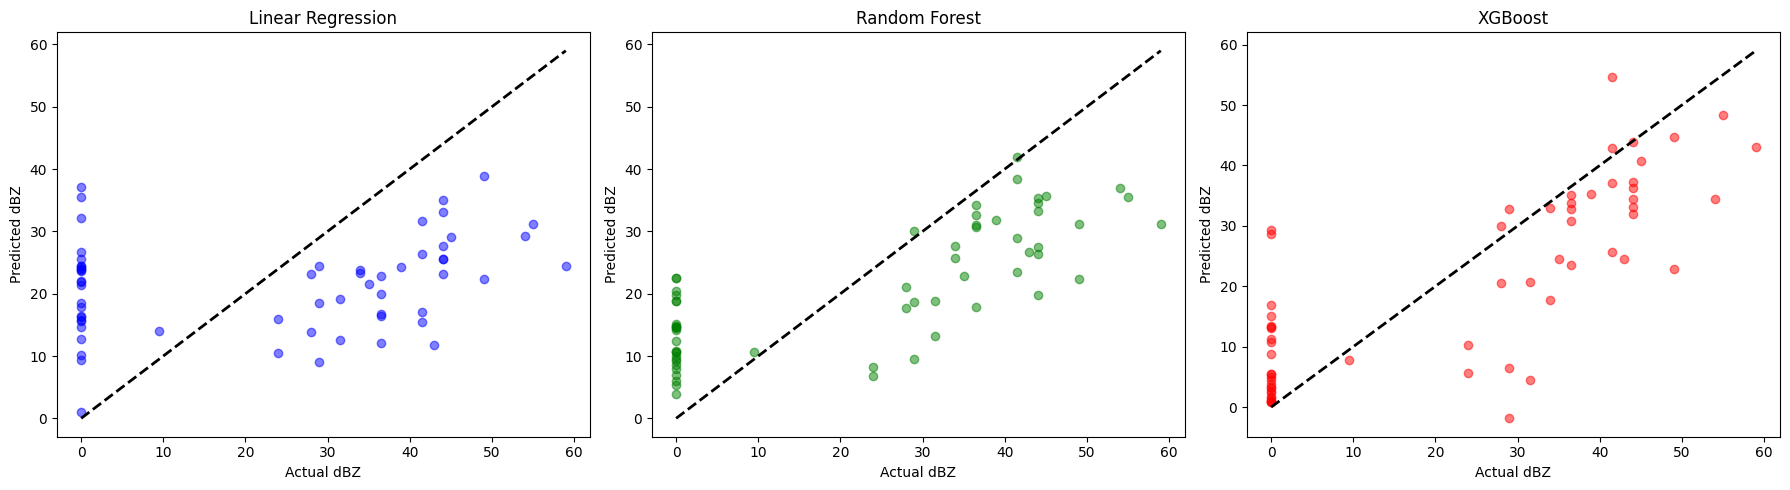

In [128]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# ===== 2. Random Forest =====
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# ===== 3. XGBoost =====
xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# ===== Evaluation Metrics =====
models = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, y_pred in models.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

# ===== Visualization =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["blue", "green", "red"]
for i, (name, y_pred) in enumerate(models.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.5, color=colors[i])
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    axes[i].set_title(name)
    axes[i].set_xlabel("Actual dBZ")
    axes[i].set_ylabel("Predicted dBZ")

plt.tight_layout()
plt.show()

# arm

In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
df = pd.read_excel("/content/data_linear_interpolated_ARM.xlsx")

# แยกตัวแปร
X = df.drop(columns=['dBZ','dBZ.1'])
y = df['dBZ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# สร้างโมเดล Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# ทำนายค่า
y_pred = rf.predict(X_test)

# ประเมินผล
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 15.058733333333336
MSE: 313.93388566666664
RMSE: 17.71817952462009
R²: 0.12768099429742608
